# Лабораторная 1: Transformer encoder для order-sensitive toy classification


## Что нужно знать до старта

Перед началом этой ЛР полезно открыть:
- [../README.md](./README.md)
- [guides/00_transformer_prerequisites.md](./guides/00_transformer_prerequisites.md)
- [guides/01_self_attention_and_positional_encoding_beginner.md](./guides/01_self_attention_and_positional_encoding_beginner.md)
- [guides/02_transformer_encoder_toy_walkthrough.md](./guides/02_transformer_encoder_toy_walkthrough.md)
- [../../02-Attention/theory/theory.md](../../02-Attention/theory/theory.md)

Это первая лабораторная блока `03-Transformer` и Шаг 5 общего курса.


## Выбор runtime

Здесь вы выбираете, где и на чём запускать notebook.

Что обычно выбирать:
- `auto` — лучший вариант по умолчанию. Если TensorFlow видит GPU, будет выбран GPU. Если GPU нет, notebook спокойно останется на CPU.
- `local-cpu` — локальный запуск только на CPU, даже если видеокарта есть.
- `local-gpu` — локальный запуск с обязательным GPU. Если GPU не настроен, notebook специально остановится с понятной ошибкой.
- `colab-cpu` / `colab-gpu` — запуск в Google Colab.
- `kaggle-cpu` / `kaggle-gpu` — запуск в Kaggle Notebooks.

Что важно:
- после изменения `RUNTIME_MODE` используйте `Restart & Run All`;
- `COURSE_REPO_HTTPS_URL` нужен только для Colab/Kaggle, если репозиторий ещё не клонирован в runtime;
- пока в ячейке стоит placeholder-URL, cloud auto-bootstrap не сможет сам скачать курс;
- guide `05` отвечает на вопрос, где и как запускать notebook;
- guide `06` нужен, если вы хотите именно локальный GPU и не уверены в версиях `TensorFlow` / `CUDA`;
- локальный GPU-path курса: `Linux + NVIDIA` или `Windows -> WSL2 + Ubuntu`;
- если `local-gpu` упирается в локальные CUDA/PTX ошибки, это обычно уже проблема GPU-стека, а не notebook. В таком случае спокойно переключайтесь на `local-cpu`, `colab-gpu` или `kaggle-gpu`.

Подробные guides:
- `themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md`
- `themes/00-Foundations/guides/06_tensorflow_cuda_version_selection.md`


In [ ]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/03-Transformer/lab/requirements.txt"


def _detect_notebook_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)

from course_runtime import setup_notebook_runtime

runtime_info = setup_notebook_runtime(
    runtime_mode=RUNTIME_MODE,
    course_repo_https_url=COURSE_REPO_HTTPS_URL,
    notebook_requirements=NOTEBOOK_REQUIREMENTS,
)
runtime_info.as_dict()


## Интуиция задачи без формул

Здесь модель решает очень специальную задачу:
- во входной последовательности точно есть токены `7` и `3`;
- метка зависит не от того, что эти токены вообще были,
- а от того, **кто встретился раньше**.

Пример:

```text
[7, 5, 2, 3, PAD, PAD, ...] -> y = 1
[3, 5, 2, 7, PAD, PAD, ...] -> y = 0
```

Набор токенов одинаковый, но порядок разный.
Это и есть главная причина, по которой Transformer encoder не может обходиться без positional embedding.


## Как проходить эту ЛР без преподавателя

Фиксированный порядок для темы `03-Transformer`:
1. Прочитать `guides/00_transformer_prerequisites.md`.
2. Прочитать `guides/01_self_attention_and_positional_encoding_beginner.md`.
3. Пройти `guides/02_transformer_encoder_toy_walkthrough.md`.
4. Сделать свою первую попытку в этом starter notebook.
5. Если застряли, открыть `guides/04_transformer_debugging_playbook.md`.
6. Сделать вторую попытку после debugging-step.
7. Только потом смотреть в `solutions/01_transformer_encoder_order_toy_solution.ipynb`.


## Что изменилось после `02-Attention / ЛР01`

В attention-лаборатории decoder смотрел на encoder.

Теперь:
- рекуррентной ячейки больше нет;
- одна и та же последовательность сама строит `query`, `key`, `value`;
- вместо `cross-attention` мы используем `self-attention`;
- positional embedding становится обязательной частью модели.


## Контракт данных

Вход:
- padded последовательности целых token ids,
- форма `X -> (N, T)`.

Выход:
- бинарная метка `y -> (N,)`.

Правило метки:
- `y = 1`, если `7` стоит раньше `3`;
- `y = 0`, если `3` стоит раньше `7`.


## Таблица форм тензоров

| Сущность | Смысл | Форма |
|---|---|---|
| `X_train` | padded token ids | `(N, T)` |
| `padding_mask` | полезные позиции | `(N, T)` |
| `embeddings` | token + position embeddings | `(N, T, E)` |
| `attention_scores` | веса внимания по головам | `(N, H, T, T)` |
| `pooled` | один вектор на объект | `(N, E)` |
| `y_pred` | вероятность класса | `(N, 1)` |


## Шпаргалка по обозначениям и формам

- `N` — число объектов.
- `T` — длина последовательности после padding.
- `E` — размер embedding / model dimension.
- `H` — число attention heads.
- `PAD = 0`.

Практический фокус этой ЛР:
- проверить shapes;
- проверить mask;
- проверить, что attention не уходит в padded хвост.


## Контракт модели

Модель должна состоять из таких блоков:
1. `TokenAndPositionEmbedding`
2. `TransformerEncoderBlock`
3. masked average pooling
4. classifier head для binary classification

Отдельно нужен tracing-path, который возвращает `attention_scores` хотя бы для одного encoder block.


## Мини-теория

Минимальный encoder block:

$$
H_1 = \mathrm{LayerNorm}(X + \mathrm{MHA}(X))
$$

$$
H_2 = \mathrm{LayerNorm}(H_1 + \mathrm{FFN}(H_1))
$$

Если positional embedding отсутствует, то attention знает “какие токены были”, но слабо знает “где они были”.
Для этой лабораторной это критично, потому что метка зависит именно от порядка.


## Ручной разбор одного примера

Сравните две последовательности:

```text
A = [7, 5, 2, 3]
B = [3, 5, 2, 7]
```

Если смотреть только на набор токенов, они одинаковы.
Но по правилу задачи:
- `A -> 1`
- `B -> 0`

Значит, модели нужен позиционный сигнал.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
SEED = 7
PAD_ID = 0
KEY_TOKEN = 7
VALUE_TOKEN = 3
VOCAB_SIZE = 16
SEQ_LEN = 12
MIN_LEN = 4
TRAIN_SIZE = 4000
TEST_SIZE = 1000
EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 64
BATCH_SIZE = 64
EPOCHS = 6

keras.utils.set_random_seed(SEED)
np.set_printoptions(linewidth=120)


## Контрольная точка 1: данные

На этом этапе нужно убедиться в трёх вещах:
- padded последовательности имеют общую длину `T`;
- токены `7` и `3` всегда присутствуют в полезной части;
- label зависит именно от порядка этих токенов.

Двигайтесь дальше только когда shape и rule label уже понятны руками.


In [5]:
filler_tokens = np.array(
    [token for token in range(1, VOCAB_SIZE) if token not in (KEY_TOKEN, VALUE_TOKEN)],
    dtype=np.int32,
)


def generate_order_dataset(num_samples, seq_len=SEQ_LEN, min_len=MIN_LEN, seed=SEED):
    """Генерирует синтетический набор для задачи чувствительности к порядку.

    Аргументы:
      num_samples: Число последовательностей для генерации.
      seq_len: Максимальная длина последовательности после дополнения.
      min_len: Минимальная полезная длина до дополнения.
      seed: Зерно случайности для воспроизводимости.

    Возвращает:
      Кортеж `(X, y, lengths)`, где:
        `X`: Матрица токенов формы `(num_samples, seq_len)`.
        `y`: Вектор бинарных меток формы `(num_samples,)`.
        `lengths`: Полезные длины до дополнения формы `(num_samples,)`.

    Исключения:
      ValueError: Если `min_len` или `seq_len` заданы некорректно.
    """
    if min_len < 2 or seq_len < min_len:
        raise ValueError('Ожидается 2 <= min_len <= seq_len.')

    rng = np.random.default_rng(seed)
    X = np.full((num_samples, seq_len), PAD_ID, dtype=np.int32)
    y = np.zeros((num_samples,), dtype=np.int32)
    lengths = np.zeros((num_samples,), dtype=np.int32)

    for i in range(num_samples):
        # TODO 1.1: выберите полезную длину в диапазоне [min_len, seq_len]
        length = rng.integers(min_len, seq_len + 1)
        lengths[i] = length

        pos_first = rng.integers(0, length - 1)
        pos_second = rng.integers(pos_first + 1, length)

        seq = rng.choice(filler_tokens, size=length)
        # TODO 1.2: соберите последовательность filler-токенов и вставьте KEY_TOKEN и VALUE_TOKEN
        seq[pos_first] = KEY_TOKEN
        seq[pos_second] = VALUE_TOKEN
        # TODO 1.3: посчитайте label по порядку этих токенов и запишите padded sequence в X
        y[i] = 1
        X[i, :length] = seq
        

    return X, y, lengths


X_all, y_all, lengths_all = generate_order_dataset(TRAIN_SIZE + TEST_SIZE)
X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
    X_all,
    y_all,
    lengths_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_all,
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train mean :', y_train.mean())


X_train shape: (4000, 12)
X_test shape : (1000, 12)
y_train mean : 1.0


In [6]:
manual_a = np.array([[7, 5, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.int32)
manual_b = np.array([[3, 5, 2, 7, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.int32)

print('manual A label should be 1')
print('manual B label should be 0')
print('useful lengths sample:', len_train[:5])
print('class balance      :', np.bincount(y_train))


manual A label should be 1
manual B label should be 0
useful lengths sample: [11 11  5 12  5]
class balance      : [   0 4000]


## Контрольная точка 2: embeddings + mask

Здесь нужно проверить две базовые идеи:
- `TokenAndPositionEmbedding` возвращает `(batch, time, embed_dim)`;
- padding mask сохраняется и потом попадёт в attention и pooling.

Если здесь shape или mask ведут себя странно, дальше в модели будет только больше шума.


In [22]:
class TokenAndPositionEmbedding(layers.Layer):
    """Складывает токенные и позиционные векторы.

    Аргументы:
      maxlen: Максимальная длина последовательности.
      vocab_size: Размер словаря токенов.
      embed_dim: Размерность векторного представления.
      **kwargs: Дополнительные аргументы базового слоя Keras.

    Возвращает:
      Экземпляр слоя встраивания токенов и позиций.

    Исключения:
      ValueError: Если `embed_dim` меньше 1.
    """

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        if embed_dim < 1:
            raise ValueError('embed_dim должен быть положительным.')
        self.token_emb = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.pos_emb = layers.Embedding(maxlen, embed_dim)
        self.supports_masking = True

    def call(self, inputs):
        """Возвращает сумму токенных и позиционных векторов.

        Аргументы:
          inputs: Целочисленные токены формы `(batch, time)`.

        Возвращает:
          Тензор формы `(batch, time, embed_dim)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 2` не реализован.
        """
        # TODO 2.1: построить позиции через tf.range
        positions = tf.range(start=0, limit=tf.shape(inputs)[1])
        # TODO 2.2: получить token embeddings и position embeddings
        token_emb = self.token_emb(inputs)
        pos_emb = self.pos_emb(positions)
        # TODO 2.3: вернуть их сумму
        return token_emb + pos_emb

    def compute_mask(self, inputs, mask=None):
        """Переадресует маску непустых токенов дальше по графу.

        Аргументы:
          inputs: Целочисленные токены формы `(batch, time)`.
          mask: Входная маска базового уровня.

        Возвращает:
          Булева маска формы `(batch, time)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 2` не реализован.
        """
        # TODO 2.4: вернуть mask от token embedding
        return self.token_emb.compute_mask(inputs, mask)


def masked_average(x, mask):
    """Вычисляет среднее по времени с учётом маски.

    Аргументы:
      x: Тензор признаков формы `(batch, time, embed_dim)`.
      mask: Булева маска полезных позиций формы `(batch, time)`.

    Возвращает:
      Усреднённый тензор формы `(batch, embed_dim)`.

    Исключения:
      ValueError: Если входной тензор имеет неверный ранг.
    """
    if x.shape.rank != 3:
        raise ValueError('Ожидается ранг 3 для тензора признаков.')
    mask = tf.cast(mask, x.dtype)
    mask = tf.expand_dims(mask, axis=-1)
    summed = tf.reduce_sum(x * mask, axis=1)
    counts = tf.reduce_sum(mask, axis=1)
    return summed / tf.maximum(counts, 1.0)


class TransformerEncoderBlock(layers.Layer):
    """Минимальный блок кодировщика трансформера.

    Аргументы:
      embed_dim: Размерность входных признаков.
      num_heads: Число голов внимания.
      ff_dim: Размер скрытого слоя позиционно-независимой сети.
      rate: Доля выключаемых нейронов в прореживании.
      **kwargs: Дополнительные аргументы базового слоя Keras.

    Возвращает:
      Экземпляр блока кодировщика.

    Исключения:
      ValueError: Если `embed_dim` не делится на `num_heads`.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim должен делиться на num_heads без остатка.')
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation='relu'),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
        self.supports_masking = True

    def call(self, inputs, mask=None, training=None, return_attention_scores=False):
        """Выполняет прямой проход блока кодировщика.

        Аргументы:
          inputs: Входной тензор формы `(batch, time, embed_dim)`.
          mask: Булева маска формы `(batch, time)`.
          training: Признак режима обучения.
          return_attention_scores: Вернуть ли дополнительно веса внимания.

        Возвращает:
          Либо выходной тензор формы `(batch, time, embed_dim)`,
          либо кортеж `(output, attention_scores)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.1: Соберите attention_mask как пересечение query и key масок.
        # Подсказка: query_mask = mask[:, :, None], key_mask = mask[:, None, :].
        attention_mask = None
        if mask is not None:
            mask_float = tf.cast(mask, tf.float32)
            query_mask = mask_float[:, :, tf.newaxis]  # (batch, T, 1)
            key_mask = mask_float[:, tf.newaxis, :]     # (batch, 1, T)
            attention_mask = query_mask * key_mask      # (batch, T, T)
            attention_mask = tf.where(attention_mask == 0, -1e9, 0)
        # TODO 3.2: Вызовите self.att(..., return_attention_scores=...).
        attn_output, attn_scores = self.att(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask,
            return_attention_scores=True,
            training=training
        )
        # TODO 3.3: Выполните residual + LayerNorm + FFN + residual + LayerNorm.
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + self.dropout2(ffn_output, training=training))
        if return_attention_scores:
          return out2, attn_scores
        return out2

    def compute_mask(self, inputs, mask=None):
        """Пробрасывает временную маску на следующий слой.

        Аргументы:
          inputs: Входной тензор признаков.
          mask: Входная булева маска.

        Возвращает:
          Та же маска без изменений.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return mask


In [23]:
sample_tokens = X_train[:2]
sample_mask = sample_tokens != PAD_ID

sample_embedding_layer = TokenAndPositionEmbedding(SEQ_LEN, VOCAB_SIZE, EMBED_DIM)
sample_encoder_block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM)

sample_embeddings = sample_embedding_layer(sample_tokens)
sample_encoded, sample_scores = sample_encoder_block(
    sample_embeddings,
    mask=sample_mask,
    return_attention_scores=True,
)

print('sample_embeddings:', sample_embeddings.shape)
print('sample_encoded   :', sample_encoded.shape)
print('sample_scores    :', sample_scores.shape)


sample_embeddings: (2, 12, 32)
sample_encoded   : (2, 12, 32)
sample_scores    : (2, 2, 12, 12)


## Контрольная точка 3: encoder block + classifier

После этого блока модель должна:
- принимать `tokens -> (batch, time)`;
- превращать их в embeddings с позициями;
- прогонять через `TransformerEncoderBlock`;
- сворачивать всё в одну вероятность `y_pred -> (batch, 1)` через `sigmoid`.


In [ ]:
keras.utils.set_random_seed(SEED)

transformer_inputs = keras.Input(shape=(SEQ_LEN,), dtype='int32', name='tokens')
padding_mask = layers.Lambda(lambda x: tf.not_equal(x, PAD_ID), name='padding_mask')(transformer_inputs)

# TODO 4.1: создать TokenAndPositionEmbedding и TransformerEncoderBlock
embedding_layer = TokenAndPositionEmbedding(SEQ_LEN, VOCAB_SIZE, EMBED_DIM)
encoder_block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM, rate=0.1)
# TODO 4.2: прогнать inputs через embedding и encoder block
x = embedding_layer(transformer_inputs)
x = encoder_block(x, mask=padding_mask, return_attention_scores=False)
# TODO 4.3: сделать masked average pooling, небольшой Dense classifier head и финальный sigmoid
def masked_avg_pooling(x, mask):
    mask_float = tf.cast(mask, tf.float32)
    mask_float = tf.expand_dims(mask_float, axis=-1)
    x_sum = tf.reduce_sum(x * mask_float, axis=1)
    mask_sum = tf.reduce_sum(mask_float, axis=1)
    return x_sum / (mask_sum + 1e-9)

x_pooled = layers.Lambda(lambda tensors: masked_avg_pooling(tensors[0], tensors[1]), name='masked_avg_pool')([x, padding_mask])
# TODO 4.4: скомпилировать model
x = layers.Dense(32, activation='relu', name='dense_1')(x_pooled)
x = layers.Dropout(0.1, name='dropout')(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs=transformer_inputs, outputs=outputs, name='transformer_classifier')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [35]:
model.summary()


Model: "transformer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 12)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 12, 32)    │        896 │ tokens[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 12)        │          0 │ tokens[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ [(None, 12, 32),  │      8,544 │ token_and_positi… │
│ (TransformerEncode… │ (None, 2, 12,     │            │ padding_mask[0][… │
│                     │ 12)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_avg_pool     │ (None, 32)        │          0 │ transformer_enco… │
│ (Lambda)            │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ masked_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,589 (123.40 KB)

 Trainable params: 10,529 (41.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,060 (82.27 KB)

## Контрольная точка 4: обучение

Перед запуском `fit` проверьте:
- classifier head действительно бинарный;
- loss = `binary_crossentropy`;
- train и validation будут сравниваться отдельно от финального test.


In [25]:
# TODO 5.1: обучить model.fit(...) с validation_split
# TODO 5.2: сохранить результат в history
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9947 - loss: 0.0436 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 2/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 9.8987e-04
Epoch 3/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 5.3078e-04
Epoch 4/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 8.7204e-04 - val_accuracy: 1.0000 - val_loss: 3.2073e-04
Epoch 5/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.7395e-04 - val_accuracy: 1.0000 - val_loss: 2.1417e-04
Epoch 6/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.4146e-04 - val_accuracy: 1.0000 - val_loss: 1.4991e-04


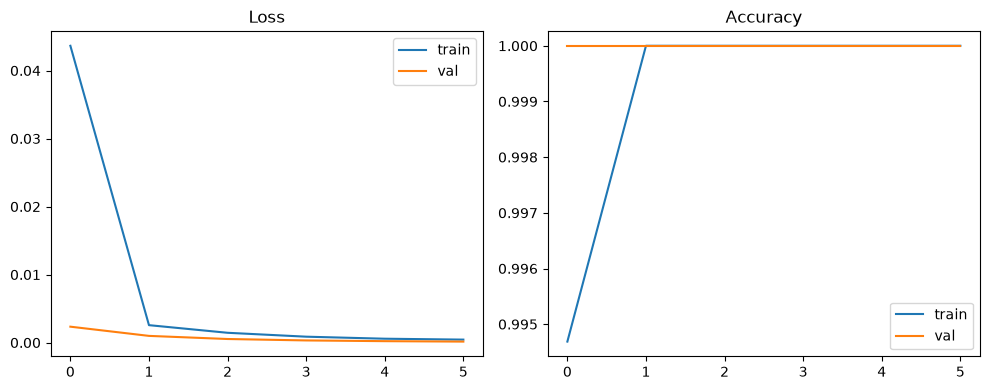

In [36]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


## Контрольная точка 5: attention trace и критерии завершения

Перед сдачей здесь должны одновременно выполняться все условия:
- `test_acc >= 0.95`;
- два ручных примера с перестановкой `7` и `3` дают разные предсказания;
- heatmap строится только по non-PAD части последовательности.

Сначала снимите итоговую метрику и ручные примеры, потом интерпретируйте attention trace.


In [37]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'test_loss = {test_loss:.4f}')
print(f'test_acc  = {test_acc:.4f}')


test_loss = 0.0001
test_acc  = 1.0000


In [38]:
paired_examples = np.array(
    [
        [7, 5, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0],
        [3, 5, 2, 7, 0, 0, 0, 0, 0, 0, 0, 0],
    ],
    dtype=np.int32,
)

paired_probs = model.predict(paired_examples, verbose=0).ravel()
for seq, prob in zip(paired_examples, paired_probs):
    label = int(prob >= 0.5)
    print(seq, '-> prob=', round(float(prob), 4), 'label=', label)


[7 5 2 3 0 0 0 0 0 0 0 0] -> prob= 0.9999 label= 1
[3 5 2 7 0 0 0 0 0 0 0 0] -> prob= 0.9999 label= 1


In [40]:
# TODO 6.1: взять один тестовый пример
sample_idx = 0
sample_tokens = X_test[sample_idx:sample_idx+1]
sample_mask = sample_tokens[0] != PAD_ID
sample_length = int(np.sum(sample_mask))

print(f"\nАнализ примера {sample_idx}:")
print(f"Токены: {sample_tokens[0][:sample_length]}")
print(f"Реальная длина: {sample_length}")

# TODO 6.2: получить attention_scores через tracing-path/model
sample_embeddings = embedding_layer(sample_tokens)

_, sample_attention = encoder_block(sample_embeddings, mask=sample_mask[None, :], return_attention_scores=True)

# TODO 6.3: усреднить attention по головам и обрезать padded хвост
mean_attention = tf.reduce_mean(sample_attention, axis=1).numpy() 
mean_attention = mean_attention[0] 

mean_attention = mean_attention[:sample_length, :sample_length]



Анализ примера 0:
Токены: [13  1  4  7  1  3]
Реальная длина: 6


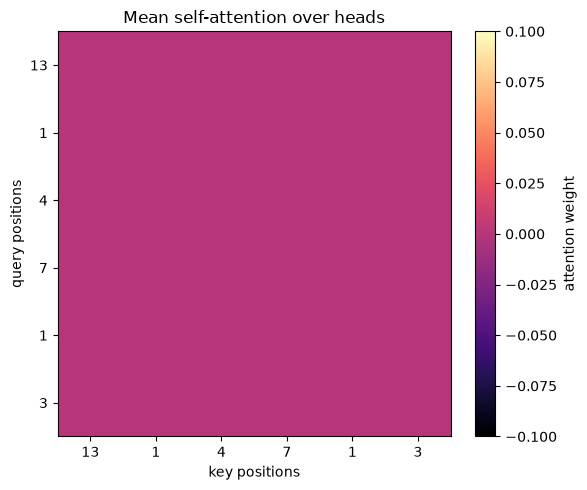

In [41]:
token_labels = [str(token) for token in sample_tokens[0][:sample_length]]

plt.figure(figsize=(6, 5))
plt.imshow(mean_attention, cmap='magma', aspect='auto')
plt.colorbar(label='attention weight')
plt.xticks(range(sample_length), token_labels)
plt.yticks(range(sample_length), token_labels)
plt.xlabel('key positions')
plt.ylabel('query positions')
plt.title('Mean self-attention over heads')
plt.tight_layout()
plt.show()


## Опционально после сдачи: почему здесь не хватает bag-of-words логики

## Если не получилось с первого раза

Не начинайте с гипотезы “Transformer слишком сложный”.
Сначала проверьте:
- rule label;
- shapes;
- mask;
- позиционное кодирование;
- форму `attention_scores`.


## Если застряли: порядок диагностики

1. Проверить два ручных примера с одинаковым набором токенов.
2. Проверить форму `embeddings`.
3. Проверить форму `attention_scores`.
4. Проверить, что attention не смотрит на `PAD`.
5. Только потом смотреть в solution notebook.


## Чек-лист перед сдачей

- Данные padded до общей длины `T`.
- `7` и `3` всегда есть в полезной части последовательности.
- `TokenAndPositionEmbedding` возвращает `(batch, time, embed_dim)`.
- `TransformerEncoderBlock` использует mask.
- Модель возвращает бинарную вероятность `y_pred -> (N, 1)` через `sigmoid`.
- `test_acc >= 0.95`.
- Два ручных примера с перестановкой `7` и `3` различаются по предсказанию.
- Attention trace визуализируется хотя бы на одном примере и обрезан до non-PAD части.


## Как использовать решение без самообмана

Правильный порядок:
1. первая самостоятельная попытка;
2. walkthrough;
3. debugging playbook;
4. вторая самостоятельная попытка;
5. только потом solution notebook.

Если просто скопировать custom layer, то можно получить зелёные ячейки без понимания, зачем нужны positional embedding и padding mask.


## Опционально после сдачи: мини-экзамен

1. Почему self-attention без позиции не решает эту задачу надёжно?
2. Зачем здесь нужна padding mask, если это не `seq2seq`?
3. Почему `attention_scores` имеют две оси времени?
4. Что именно делает residual connection в encoder block?


## Опционально после сдачи: что дальше

Эта лабораторная закрывает synthetic-вход в `Transformer encoder`.

Следующий шаг курса — `03-Transformer / ЛР02`, где тот же блок переносится на реальный `IMDB`:
- вход уже не synthetic sequence, а review;
- метка остаётся одна на последовательность;
- self-attention и positional embedding остаются центральными.

Открывать дальше: [02_transformer_encoder_imdb.ipynb](./02_transformer_encoder_imdb.ipynb)


## Опционально после сдачи: вопросы для самопроверки

## Типичные ошибки (симптом -> причина -> исправление)

- `attention_scores` неожиданной формы -> перепутано ожидание выхода `MultiHeadAttention` -> помнить про `(batch, heads, T, T)`.
- Accuracy около `0.5` -> метка считается не по позиции, а по наличию токенов -> проверить rule label.
- Heatmap яркий на padded хвосте -> mask не передан в attention -> проверить `padding_mask`.
- Порядок не влияет на модель -> забыли positional embedding -> проверить `TokenAndPositionEmbedding`.
